In [15]:
import torch
from torchvision import datasets, transforms

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 将图像转换为张量
    transforms.Normalize((0.5,), (0.5,))  # 归一化到 [-1, 1]
])

# 加载训练集和测试集
train_dataset = datasets.FashionMNIST(
    root='./data',  # 数据集保存路径
    train=True,     # 加载训练集
    download=True,  # 如果数据集不存在，则下载
    transform=transform  # 应用预处理
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,    # 加载测试集
    download=True,
    transform=transform
)

100.0%


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%

Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



In [16]:
from torch.utils.data import DataLoader

# 定义批次大小
batch_size = 64

# 创建数据加载器
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True  # 打乱数据
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False  # 测试集不需要打乱
)

In [20]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 将图像转换为张量，
    transforms.Normalize((0.5,), (0.5,))  # 归一化到 [-1, 1]
])

# 加载 FashionMNIST 数据集
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=False,
    transform=transform
)

# 创建数据加载器
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=1,  # 每次加载一个样本
    shuffle=True   # 打乱数据
)

In [21]:
# 从数据加载器中获取一个随机样本
data_iter = iter(train_loader)
images, labels = next(data_iter)

# 打印张量的形状和内容
print("张量形状:", images.shape)  # 输出: torch.Size([1, 1, 28, 28])
print("张量值:\n", images)

张量形状: torch.Size([1, 1, 28, 28])
张量值:
 tensor([[[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.00

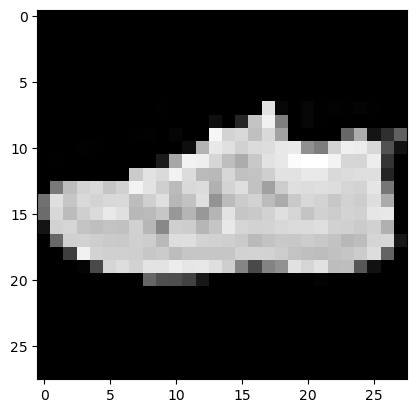

In [22]:
image = images.squeeze()
plt.imshow(image, cmap='gray')

In [7]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image


class FashionMNISTDataset(Dataset):
    def __init__(self, data_dir, train=True, transform=None):
        """
        参数:
        - data_dir: 数据集根目录。
        - train: 是否为训练集（True 表示训练集，False 表示测试集）。
        - transform: 可选的数据预处理或增强操作。
        """
        self.data_dir = data_dir
        self.train = train
        self.transform = transform

        # 加载数据
        if self.train:
            self.images = self.load_images(
                os.path.join(data_dir, 'train-images-idx3-ubyte')
            )
            self.labels = self.load_labels(
                os.path.join(data_dir, 'train-labels-idx1-ubyte'))
        else:
            self.images = self.load_images(
                os.path.join(data_dir, 't10k-images-idx3-ubyte'))
            self.labels = self.load_labels(
                os.path.join(data_dir, 't10k-labels-idx1-ubyte'))

    def load_images(self, path):
        """加载图像数据"""
        with open(path, 'rb') as f:
            # 跳过文件头（16 字节）
            f.read(16)
            # 读取图像数据
            data = np.frombuffer(f.read(), dtype=np.uint8)
            # 转换为形状为 (num_samples, 28, 28) 的数组
            data = data.reshape(-1, 28, 28)
        return data

    def load_labels(self, path):
        """加载标签数据"""
        with open(path, 'rb') as f:
            # 跳过文件头（8 字节）
            f.read(8)
            # 读取标签数据
            labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

    def __len__(self):
        """返回数据集的大小"""
        return len(self.images)

    def __getitem__(self, idx):
        """
        根据索引返回一个样本
        参数:
        - idx: 样本的索引
        返回:
        - 一个包含图像和标签的元组
        """
        image = self.images[idx]
        label = self.labels[idx]

        # 将 NumPy 数组转换为 PIL 图像
        image = Image.fromarray(image, mode='L')

        # 如果有预处理操作，则应用
        if self.transform:
            image = self.transform(image)

        return image, label


# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 将图像转换为张量
    transforms.Normalize((0.5,), (0.5,))  # 归一化到 [-1, 1]
])

# 创建自定义 Dataset
data_dir = 'data/FashionMNIST/raw'
train_dataset = FashionMNISTDataset(data_dir, train=True, transform=transform)
test_dataset = FashionMNISTDataset(data_dir, train=False, transform=transform)

# 创建 DataLoader
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False)

# 测试 DataLoader
for images, labels in train_loader:
    print("Images shape:", images.shape)  # 输出: torch.Size([32, 1, 28, 28])
    print("Labels:", labels)
    break

Images shape: torch.Size([32, 1, 28, 28])
Labels: tensor([5, 4, 5, 7, 5, 9, 2, 4, 4, 9, 8, 1, 1, 4, 7, 4, 4, 1, 9, 8, 6, 4, 0, 2,
        5, 3, 0, 4, 5, 1, 2, 6], dtype=torch.uint8)
